Import all libraries that will be used for EDA

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sbn


1. Download data as a dataframe and get close data

In [41]:
tickers = ["SPY", "^VIX", "QQQ", "IWM", "GLD", "TLT"]
df = yf.download(tickers, start="2005-01-01", end="2024-01-01", interval="1d")

close = df["Close"]


/var/folders/g0/nsxm0s0x64z69dg0l2b9mf4m0000gn/T/ipykernel_2630/2966925848.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2005-01-01", end="2024-01-01", interval="1d")
[*********************100%***********************]  6 of 6 completed


2. Get Summary Statistics of for the Price at Close from 2005-2024 for the SPY, VIX, and SPY_return

In [42]:
close["SPY_return"] = close["SPY"].pct_change()

print(close[["SPY", "^VIX", "SPY_return"]].describe())



Ticker          SPY         ^VIX   SPY_return
count   4781.000000  4781.000000  4780.000000
mean     188.529183    19.340554     0.000438
std      112.477940     8.938361     0.012168
min       49.808578     9.140000    -0.109424
25%       95.860100    13.350000    -0.004076
50%      157.900375    16.870001     0.000673
75%      255.210938    22.540001     0.005807
max      463.923035    82.690002     0.145197


/var/folders/g0/nsxm0s0x64z69dg0l2b9mf4m0000gn/T/ipykernel_2630/3695386662.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close["SPY_return"] = close["SPY"].pct_change()


3. Identify how frequently VIX is above 30 at close (highly volatile days)

In [43]:
high_vix = (close["^VIX"] > 30).sum()
days = close["^VIX"].dropna().shape[0]

print(days)
print(high_vix)
print(high_vix/days)

4781
434
0.09077598828696926


4. Vizualizing VIX During and Outside of Crisis Periods

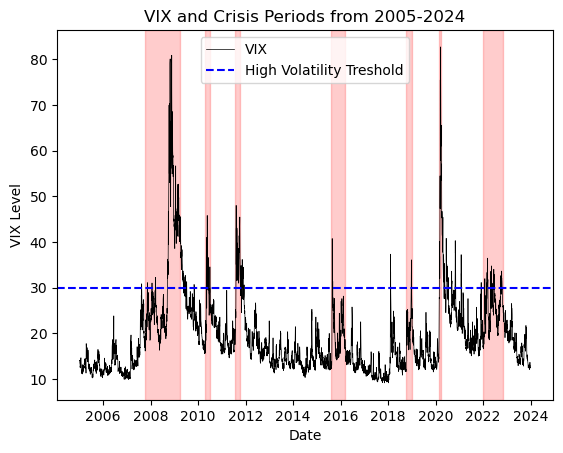

In [44]:
# Crisis Periods were generated using AI and Capture Well-Documented Periods of Abnormal Market Behavior Across the Market
crisis_periods = [
    ("2007-10-01", "2009-03-31", "GFC"),
    ("2010-04-23", "2010-07-02", "Flash Crash"),
    ("2011-07-22", "2011-10-03", "Debt Ceiling"),
    ("2015-08-01", "2016-02-29", "China/Oil"),
    ("2018-10-01", "2018-12-31", "Rate Hike"),
    ("2020-02-19", "2020-03-23", "COVID"),
    ("2022-01-01", "2022-10-31", "Inflation"),
]

fig, ax = plt.subplots()

ax.plot(close.index, close["^VIX"], color="black", linewidth=0.5, label = "VIX")
ax.axhline(y=30, color = "blue", linestyle="--", label = "High Volatility Treshold")
for s, e, l in crisis_periods:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.2, color="red")

ax.set_title("VIX and Crisis Periods from 2005-2024")   
ax.set_xlabel("Date")
ax.set_ylabel("VIX Level")
ax.legend()
plt.savefig("visualizations/vix_crisis.png")
plt.show()


5. Vizualizing SPY Drawdown During and Outside of Crisis Periods

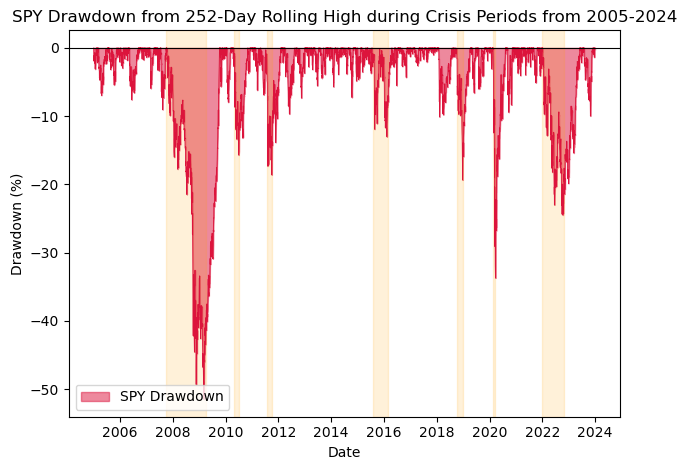

In [45]:

rolling_max = close["SPY"].rolling(window=252, min_periods=1).max()
drawdown = (close["SPY"] - rolling_max) / rolling_max * 100  

fig, ax = plt.subplots()

ax.fill_between(close.index, drawdown, 0, color="crimson", alpha=0.5, label="SPY Drawdown")
ax.plot(close.index, drawdown, color="crimson", linewidth=0.6)

for s, e, l in crisis_periods:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color="orange", label=l)

ax.set_title("SPY Drawdown from 252-Day Rolling High during Crisis Periods from 2005-2024")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown (%)")
ax.axhline(y=0, color="black", linewidth=0.8)
ax.legend(["SPY Drawdown"], loc="lower left")
plt.tight_layout()
plt.savefig("visualizations/spy_drawdown.png", dpi=150)
plt.show()